<a href="https://colab.research.google.com/github/xadymjoop/BEICG/blob/branch/Projet%20BML%20Khadim%20DIOP%20L3DAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EXAMEN BASE MACHINE LEARNING | KHADIM DIOP

## PROBLEME 1: Ajustement polynomial des données COVID-19



In [9]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.integrate import odeint

### Chargement et préparation des données

In [12]:
# Chargement des données
df = pd.read_csv('/content/drive/MyDrive/Ml_covid19/covid.csv', sep=";", encoding="utf-8")
print(df.head())  # Voir un aperçu des colonnes




         date      country  confirmed  Deaths  recovered  Active  New cases  \
0  22/01/2020  Afghanistan          0       0          0       0          0   
1  22/01/2020      Albania          0       0          0       0          0   
2  22/01/2020      Algeria          0       0          0       0          0   
3  22/01/2020      Andorra          0       0          0       0          0   
4  22/01/2020       Angola          0       0          0       0          0   

   New deaths  New recovered             WHO Region  
0           0              0  Eastern Mediterranean  
1           0              0                 Europe  
2           0              0                 Africa  
3           0              0                 Europe  
4           0              0                 Africa  


In [13]:
print(df.columns)


Index(['date', 'country', 'confirmed', 'Deaths', 'recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region'],
      dtype='object')


In [14]:
# Conversion de la colonne date en datetime
df['date'] = pd.to_datetime(df['date'], format="%d/%m/%Y")

# Filtrage pour la période 2020-2021
df = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2021-12-31')]
 # Liste des pays demandés
pays = ['Senegal', "Cote d'Ivoire", 'Burkina Faso', 'France', 'US']

# Agrégation des données par pays et par date
df_pays = df[df['country'].isin(pays)].groupby(['country', 'date']).agg({
    'confirmed': 'sum',
    'recovered': 'sum'
}).reset_index()

# Tri par pays et date
df_pays = df_pays.sort_values(['country', 'date'])

# Calcul des cas cumulés par pays
for country in pays:
    mask = df_pays['country'] == country
    df_pays.loc[mask, 'confirmed_cum'] = df_pays.loc[mask, 'confirmed'].cumsum()
    df_pays.loc[mask, 'recovered_cum'] = df_pays.loc[mask, 'recovered'].cumsum()

In [15]:
print(df_pays.head())  # Voir un aperçu des colonnes


        country       date  confirmed  recovered  confirmed_cum  recovered_cum
0  Burkina Faso 2020-01-22          0          0            0.0            0.0
1  Burkina Faso 2020-01-23          0          0            0.0            0.0
2  Burkina Faso 2020-01-24          0          0            0.0            0.0
3  Burkina Faso 2020-01-25          0          0            0.0            0.0
4  Burkina Faso 2020-01-26          0          0            0.0            0.0


In [16]:
def fit_polynomial(country_data, target, degree_range=(3, 8)):

    # Conversion des dates en jours depuis le début
    dates = country_data['date']
    start_date = dates.min()
    x = (dates - start_date).dt.days.values.reshape(-1, 1)
    y = country_data[target].values

     # Séparation en train/test (80/20)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

    results = {}

    for degree in range(degree_range[0], degree_range[1] + 1):
        # Création des features polynomiales
        poly = PolynomialFeatures(degree=degree)
        x_poly_train = poly.fit_transform(x_train)
        x_poly_test = poly.transform(x_test)

        # Entraînement du modèle
        model = LinearRegression()
        model.fit(x_poly_train, y_train)

        # Prédictions
        y_pred_train = model.predict(x_poly_train)
        y_pred_test = model.predict(x_poly_test)

        # Calcul des métriques
        mse_train = mean_squared_error(y_train, y_pred_train)
        mse_test = mean_squared_error(y_test, y_pred_test)
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)

        # Stockage des résultats
        results[degree] = {
            'model': model,
            'poly': poly,
            'mse_train': mse_train,
            'mse_test': mse_test,
            'r2_train': r2_train,
            'r2_test': r2_test,
            'y_pred_train': y_pred_train,
            'y_pred_test': y_pred_test
        }

    return results

### Application aux cas confirmés cumulés



In [17]:
# Dictionnaire pour stocker tous les résultats
all_results_confirmed = {}

for country in pays:
    print(f"\nAnalyse pour {country} - Cas confirmés cumulés")
    country_data = df_pays[df_pays['country'] == country]
    results = fit_polynomial(country_data, 'confirmed_cum')
    all_results_confirmed[country] = results

    # Affichage des performances
    print(f"{'Degré':<10}{'MSE Train':<15}{'MSE Test':<15}{'R² Train':<15}{'R² Test':<15}")
    for degree, metrics in results.items():
        print(f"{degree:<10}{metrics['mse_train']:<15.2f}{metrics['mse_test']:<15.2f}"
              f"{metrics['r2_train']:<15.4f}{metrics['r2_test']:<15.4f}")


Analyse pour Senegal - Cas confirmés cumulés
Degré     MSE Train      MSE Test       R² Train       R² Test        
3         7105272.83     34203842.27    0.9964         0.9953         
4         1178004.61     2324356811.16  0.9994         0.6810         
5         732680.04      202493875.84   0.9996         0.9722         
6         199360.59      5737386974.68  0.9999         0.2126         
7         209564.61      11707453641.94 0.9999         -0.6067        
8         231381.97      11774508047.67 0.9999         -0.6159        

Analyse pour Cote d'Ivoire - Cas confirmés cumulés
Degré     MSE Train      MSE Test       R² Train       R² Test        
3         2564040.54     12143769968.13 0.9986         0.2766         
4         1220720.43     7250929443.71  0.9993         0.5680         
5         1103049.11     4605228771.91  0.9994         0.7257         
6         333053.73      2067385491.02  0.9998         0.8768         
7         27121.26       37686673086.19 1.0000    

### Application aux cas guéris cumulés

In [18]:
# Dictionnaire pour stocker tous les résultats
all_results_recovered = {}

for country in pays:
    print(f"\nAnalyse pour {country} - Cas guéris cumulés")
    country_data = df_pays[df_pays['country'] == country]
    results = fit_polynomial(country_data, 'recovered_cum')
    all_results_recovered[country] = results

    # Affichage des performances
    print(f"{'Degré':<10}{'MSE Train':<15}{'MSE Test':<15}{'R² Train':<15}{'R² Test':<15}")
    for degree, metrics in results.items():
        print(f"{degree:<10}{metrics['mse_train']:<15.2f}{metrics['mse_test']:<15.2f}"
              f"{metrics['r2_train']:<15.4f}{metrics['r2_test']:<15.4f}")


Analyse pour Senegal - Cas guéris cumulés
Degré     MSE Train      MSE Test       R² Train       R² Test        
3         5687305.25     849570301.64   0.9878         0.7368         
4         306213.12      495412584.34   0.9993         0.8465         
5         30259.28       2392132262.18  0.9999         0.2588         
6         30122.61       2534575601.83  0.9999         0.2147         
7         23753.13       933321867.52   0.9999         0.7108         
8         23436.40       392819070.69   0.9999         0.8783         

Analyse pour Cote d'Ivoire - Cas guéris cumulés
Degré     MSE Train      MSE Test       R² Train       R² Test        
3         863940.49      2543066438.92  0.9977         0.4416         
4         216927.56      1101506880.57  0.9994         0.7581         
5         192501.67      1692996867.59  0.9995         0.6282         
6         152797.62      279270602.13   0.9996         0.9387         
7         45619.34       4501011328.83  0.9999         0

### Visualisation des résultats

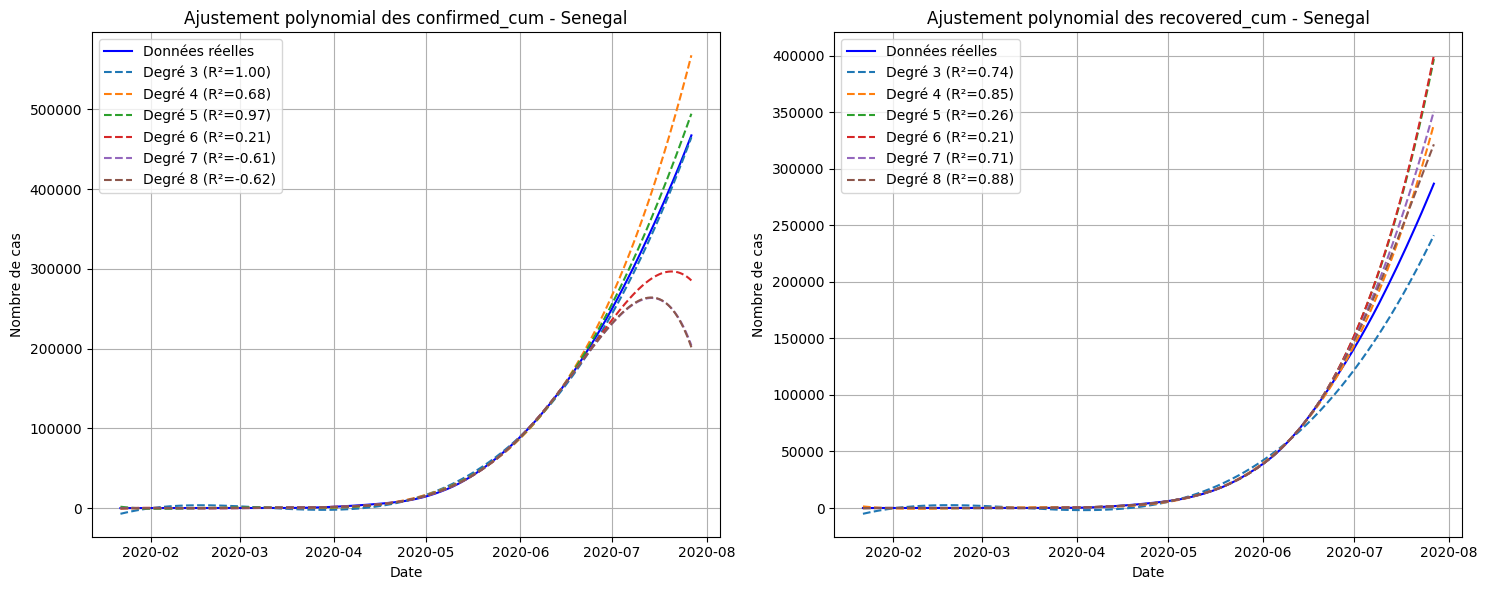

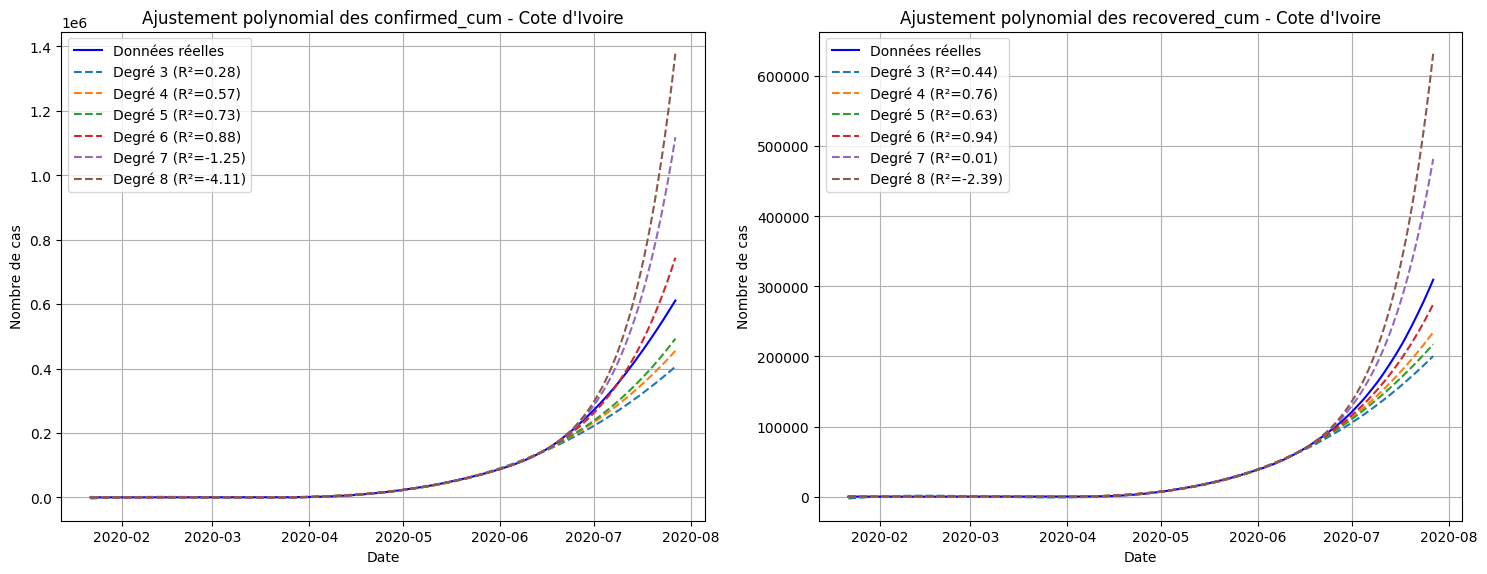

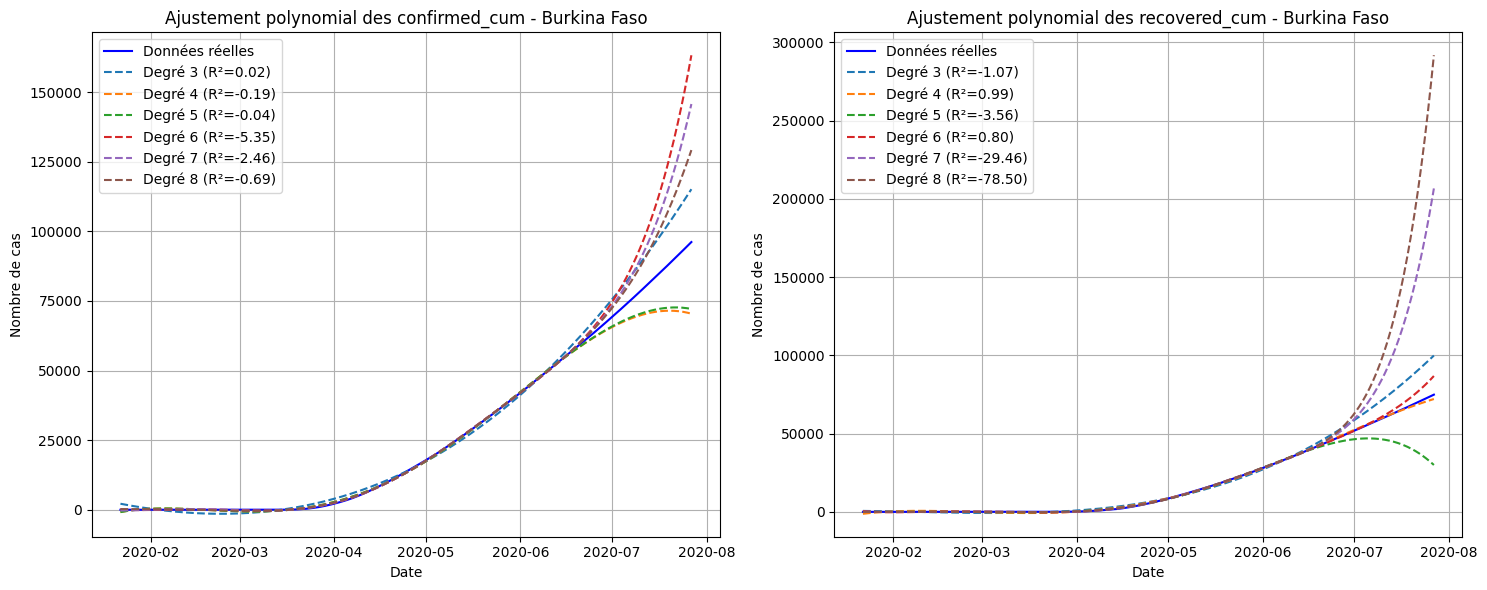

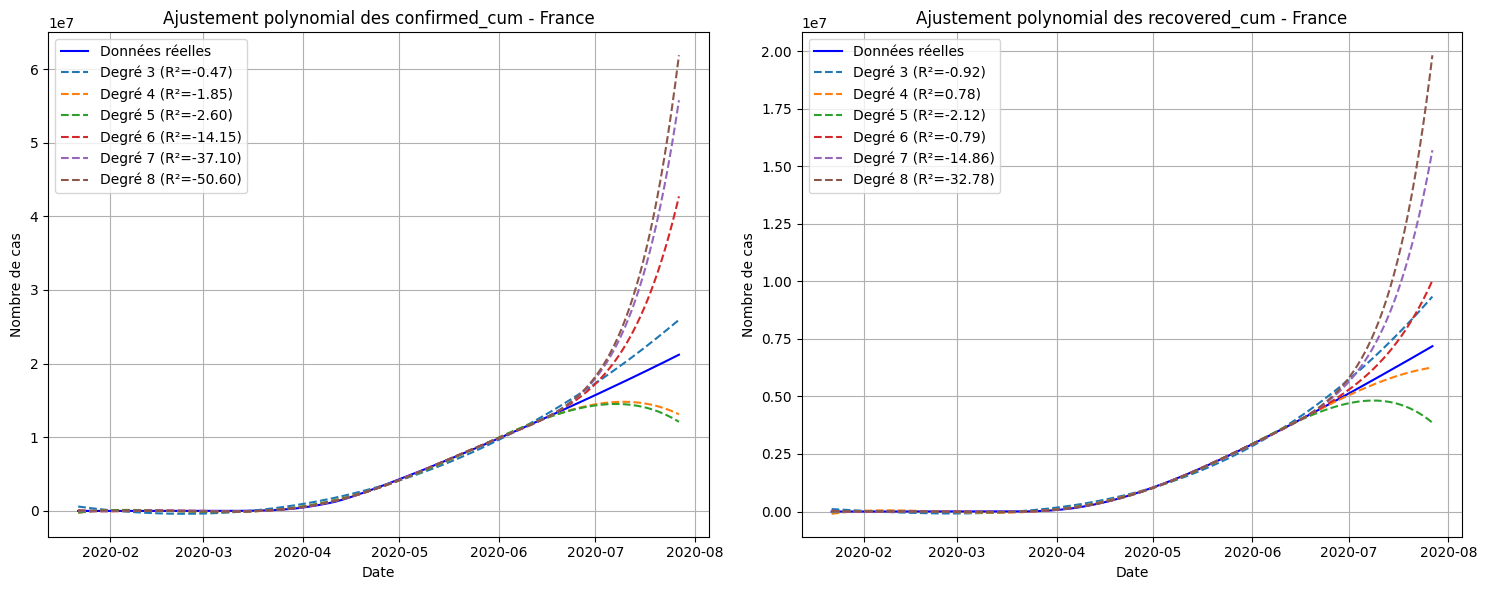

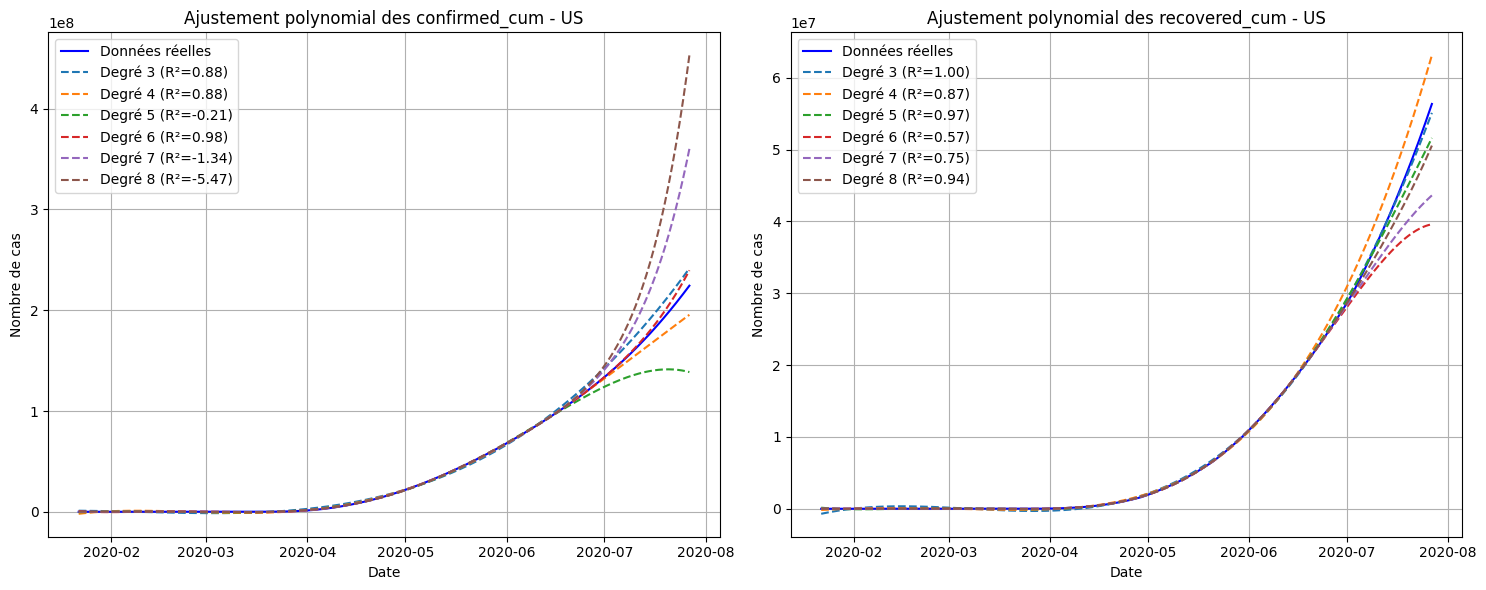

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_results(ax, country_data, results, target, country):
    dates = country_data['date']
    start_date = dates.min()
    x = (dates - start_date).dt.days.values
    y = country_data[target].values

    # Séparation train/test
    split_idx = int(len(x) * 0.8)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Données réelles
    ax.plot(dates, y, 'b-', label='Données réelles')

    # Pour chaque degré, afficher les prédictions
    for degree, metrics in results.items():
        poly = metrics['poly']
        model = metrics['model']

        # Prédiction sur l'ensemble des données pour la courbe
        x_all = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
        x_all_poly = poly.transform(x_all)
        y_all_pred = model.predict(x_all_poly)

        # Conversion des jours en dates pour l'affichage
        pred_dates = [start_date + pd.Timedelta(days=float(day[0])) for day in x_all]

        ax.plot(pred_dates, y_all_pred, '--',
                label=f'Degré {degree} (R²={metrics["r2_test"]:.2f})')

    ax.set_title(f'Ajustement polynomial des {target} - {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Nombre de cas')
    ax.legend()
    ax.grid(True)

# Affichage pour chaque pays et chaque cible ( confirmés et Guéris)
for country in pays:
    country_data = df_pays[df_pays['country'] == country]


    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Cas confirmés
    plot_results(axes[0], country_data, all_results_confirmed[country], 'confirmed_cum', country)

    # Cas guéris
    plot_results(axes[1], country_data, all_results_recovered[country], 'recovered_cum', country)

    # Affichage
    plt.tight_layout()
    plt.show()


## Problème 2: Modèle de Lokta-Volterra appliqué au COVID-19

In [20]:
populations = {
    'Senegal': 18687800,
    "Cote d'Ivoire": 31165654,
    'Burkina Faso': 24436_925,
    'France': 66650804,
    'US': 347275807
}



# Préparation des données pour Lokta-Volterra
df_lv = df_pays.copy()

for country in pays:
    mask = df_lv['country'] == country
    pop_total = populations[country]

    # Calcul des variables nécessaires
    df_lv.loc[mask, 'x(t)'] = pop_total - df_lv.loc[mask, 'confirmed_cum'] - df_lv.loc[mask, 'recovered_cum']
    df_lv.loc[mask, 'y(t)'] = df_lv.loc[mask, 'confirmed_cum']

    # Calcul des différences pour Y(t)
    df_lv.loc[mask, 'x(t+1)'] = df_lv.loc[mask, 'x(t)'].shift(-1)
    df_lv.loc[mask, 'y(t+1)'] = df_lv.loc[mask, 'y(t)'].shift(-1)

    df_lv.loc[mask, 'Y1(t)'] = df_lv.loc[mask, 'x(t+1)'] - df_lv.loc[mask, 'x(t)']
    df_lv.loc[mask, 'Y2(t)'] = df_lv.loc[mask, 'y(t+1)'] - df_lv.loc[mask, 'y(t)']

    # Calcul des variables X
    df_lv.loc[mask, 'X1_1(t)'] = df_lv.loc[mask, 'x(t)']
    df_lv.loc[mask, 'X2_1(t)'] = -df_lv.loc[mask, 'y(t)'] * df_lv.loc[mask, 'x(t)']

    df_lv.loc[mask, 'X1_2(t)'] = df_lv.loc[mask, 'y(t)'] * df_lv.loc[mask, 'x(t)']
    df_lv.loc[mask, 'X2_2(t)'] = -df_lv.loc[mask, 'y(t)']

# Suppression des lignes avec NaN (dû au shift)
df_lv = df_lv.dropna()

### Estimation des paramètres pour la première équation

In [21]:
# Dictionnaire pour stocker les paramètres
params_eq1 = {}

for country in pays:
    country_data = df_lv[df_lv['country'] == country]

    # Préparation des matrices
    Y = country_data['Y1(t)'].values.reshape(-1, 1)
    X = country_data[['X1_1(t)', 'X2_1(t)']].values

    # Régression linéaire
    model = LinearRegression()
    model.fit(X, Y)

    # Extraction des paramètres
    alpha_epsilon = model.coef_[0][0]  # α - ε
    beta = model.coef_[0][1]          # β

    params_eq1[country] = {
        'α - ε': alpha_epsilon,
        'β': beta,
        'intercept': model.intercept_[0],
        'r2_score': model.score(X, Y)
    }

    print(f"\nParamètres pour {country} - Première équation:")
    print(f"α - ε = {alpha_epsilon:.6f}")
    print(f"β = {beta:.6f}")
    print(f"R² = {params_eq1[country]['r2_score']:.4f}")


Paramètres pour Senegal - Première équation:
α - ε = -0.136381
β = 0.000000
R² = 0.9988

Paramètres pour Cote d'Ivoire - Première équation:
α - ε = -0.118640
β = 0.000000
R² = 0.9981

Paramètres pour Burkina Faso - Première équation:
α - ε = -0.142914
β = 0.000000
R² = 0.9986

Paramètres pour France - Première équation:
α - ε = -0.020130
β = 0.000000
R² = 0.9184

Paramètres pour US - Première équation:
α - ε = 0.015912
β = 0.000000
R² = 0.9776


### Estimation des paramètres pour la seconde équation

In [22]:
# Dictionnaire pour stocker les paramètres
params_eq2 = {}

for country in pays:
    country_data = df_lv[df_lv['country'] == country]

    # Préparation des matrices
    Y = country_data['Y2(t)'].values.reshape(-1, 1)
    X = country_data[['X1_2(t)', 'X2_2(t)']].values

    # Régression linéaire
    model = LinearRegression()
    model.fit(X, Y)

    # Extraction des paramètres
    delta = model.coef_[0][0]         # δ
    gamma_phi = -model.coef_[0][1]    # γ + φ

    params_eq2[country] = {
        'δ': delta,
        'γ + φ': gamma_phi,
        'intercept': model.intercept_[0],
        'r2_score': model.score(X, Y)
    }

    print(f"\nParamètres pour {country} - Seconde équation:")
    print(f"δ = {delta:.6f}")
    print(f"γ + φ = {gamma_phi:.6f}")
    print(f"R² = {params_eq2[country]['r2_score']:.4f}")


Paramètres pour Senegal - Seconde équation:
δ = 0.000000
γ + φ = -0.485818
R² = 0.9892

Paramètres pour Cote d'Ivoire - Seconde équation:
δ = 0.000000
γ + φ = -0.559563
R² = 0.9966

Paramètres pour Burkina Faso - Seconde équation:
δ = 0.000000
γ + φ = -2.677770
R² = 0.9186

Paramètres pour France - Seconde équation:
δ = 0.000000
γ + φ = -0.022145
R² = 0.8868

Paramètres pour US - Seconde équation:
δ = 0.000000
γ + φ = 0.014855
R² = 0.9682


### Simulation des resultats

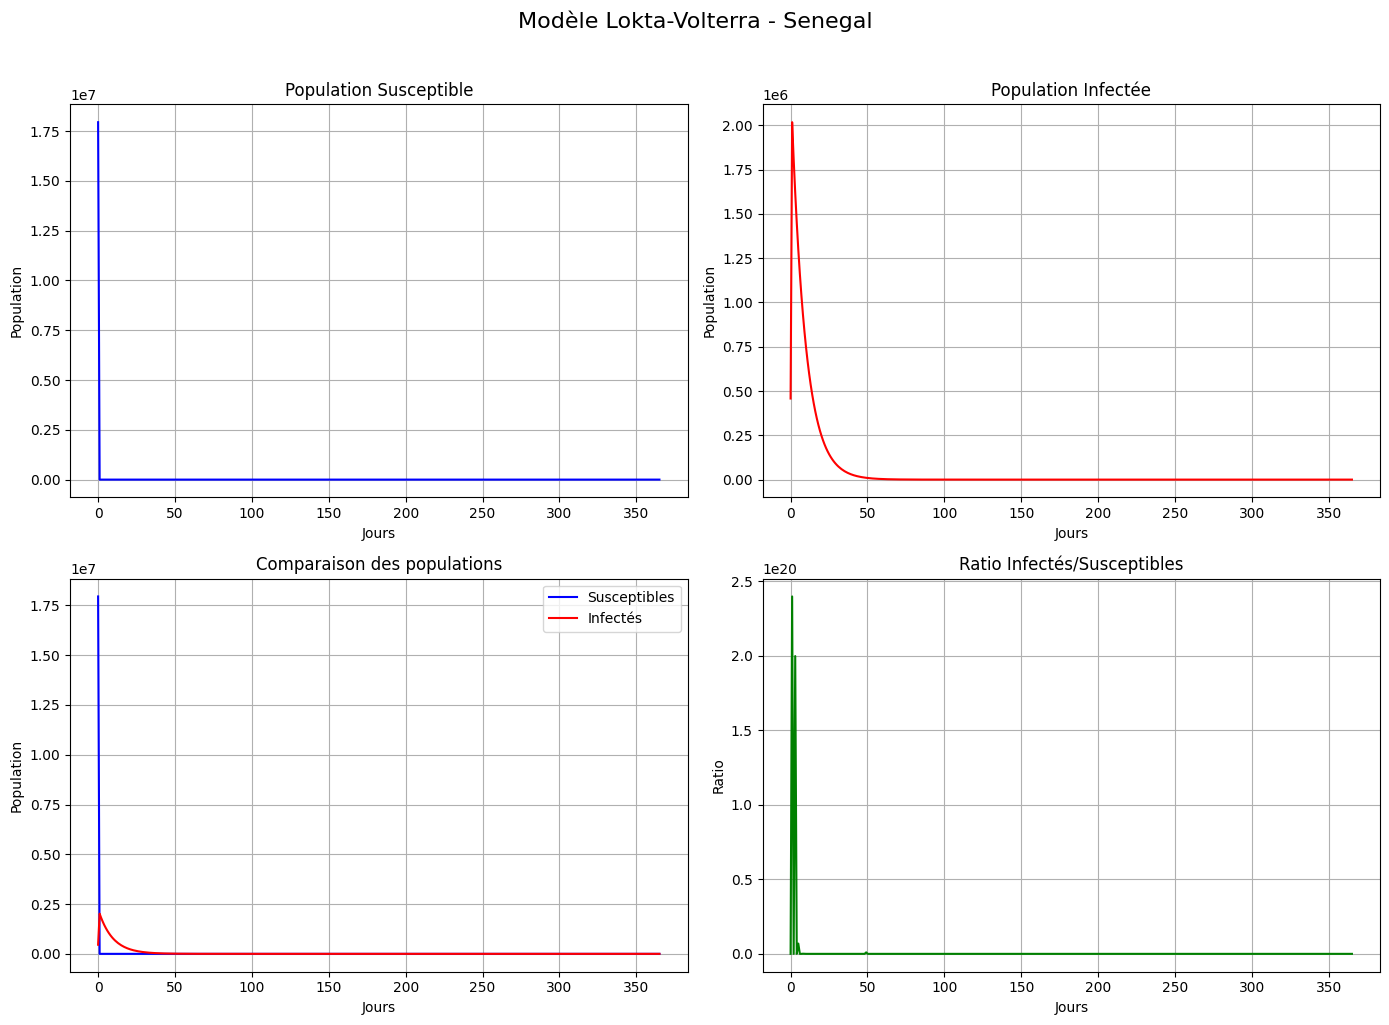

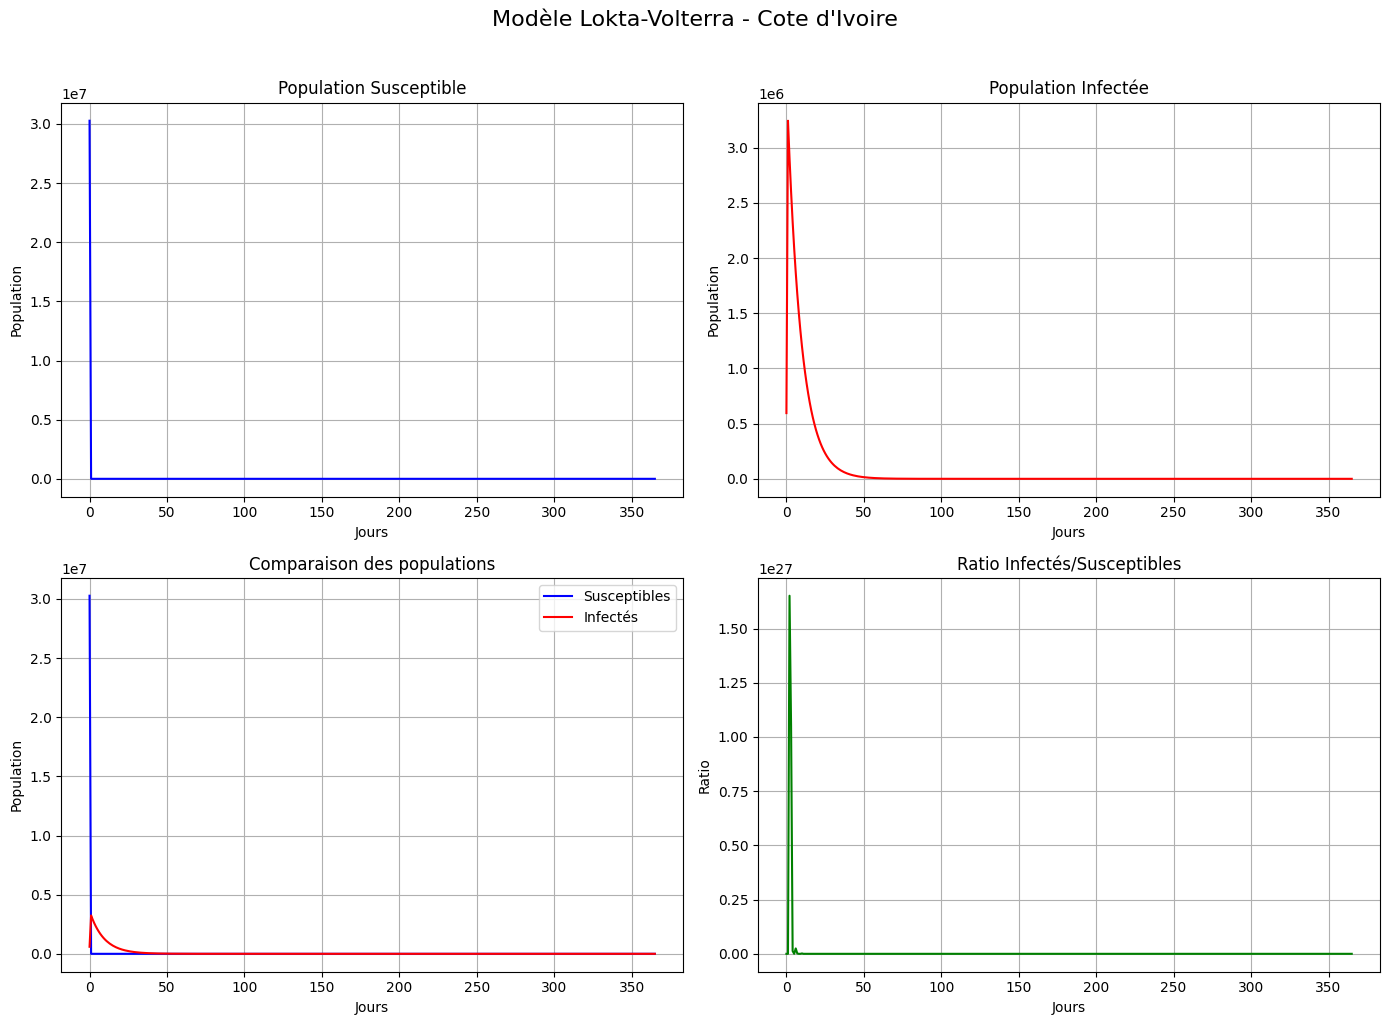

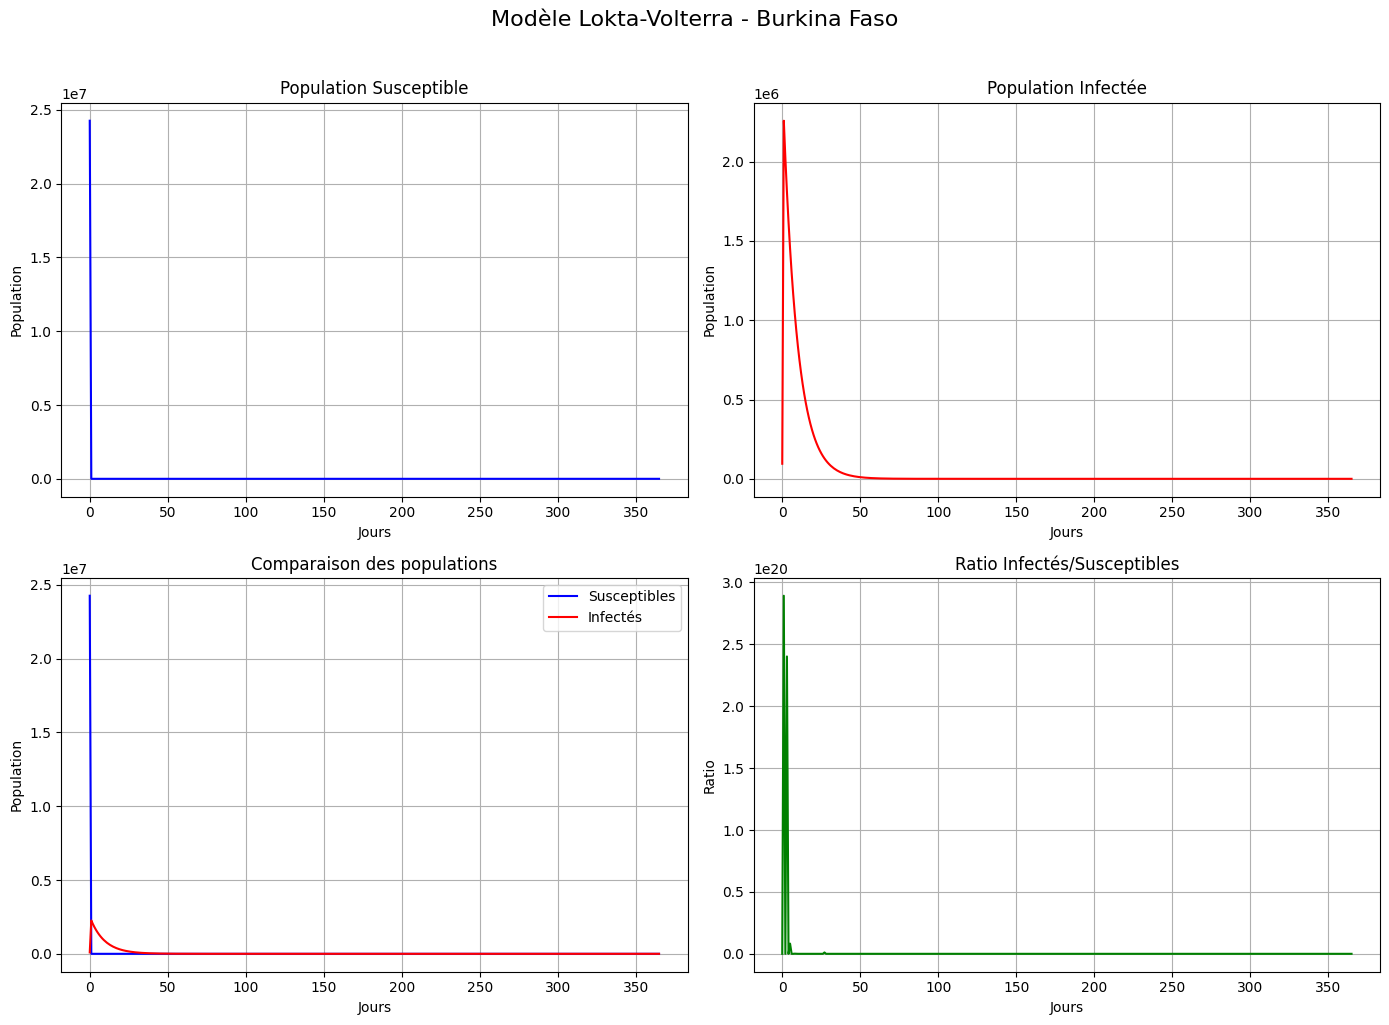

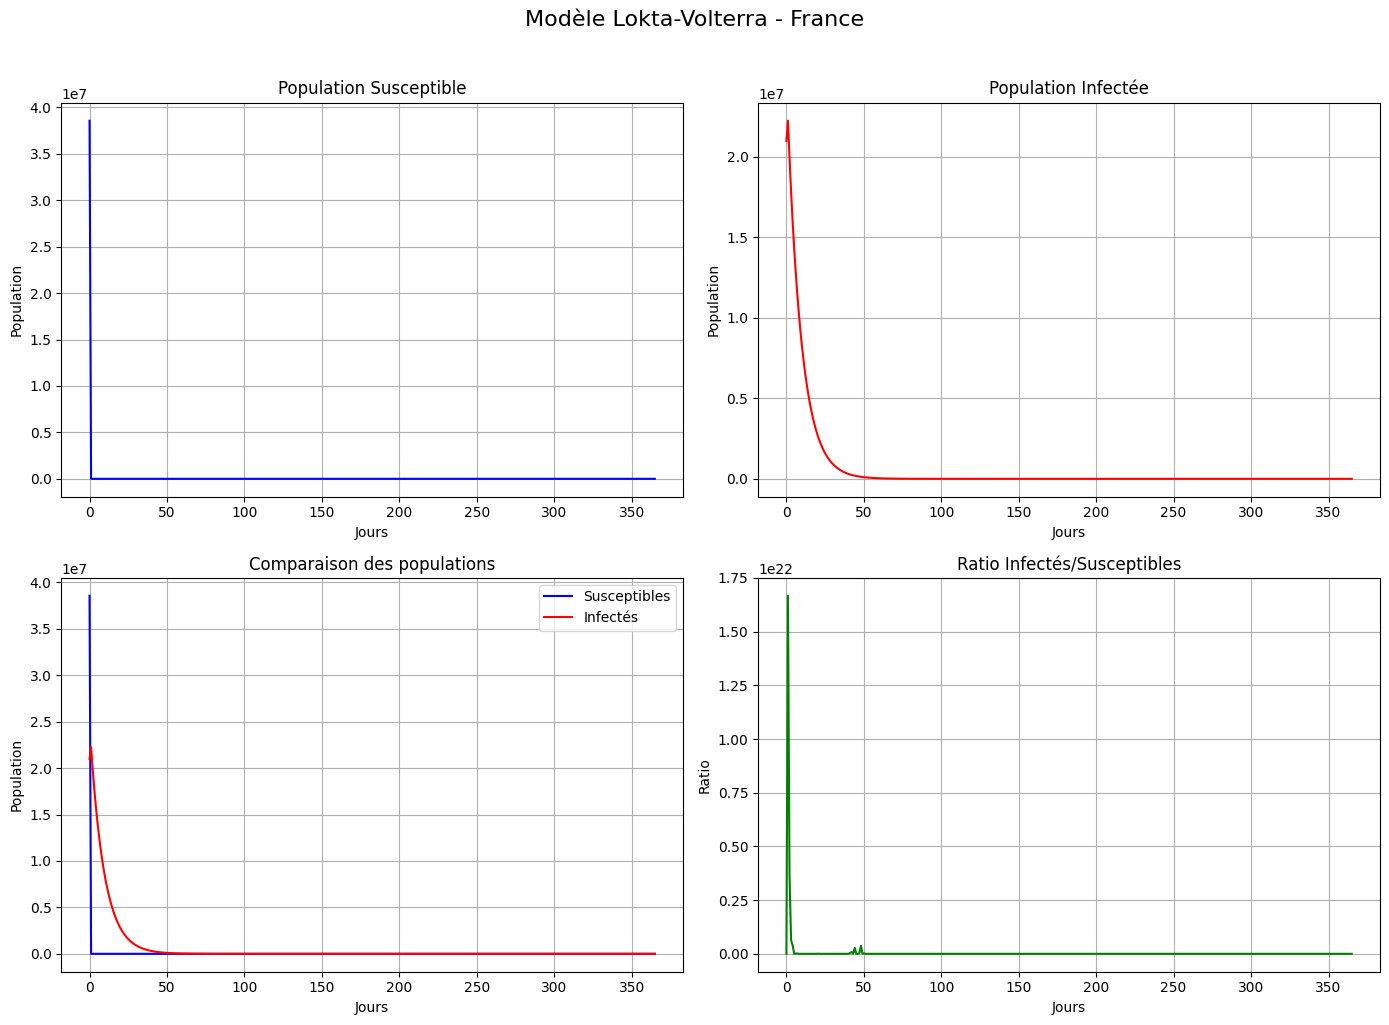

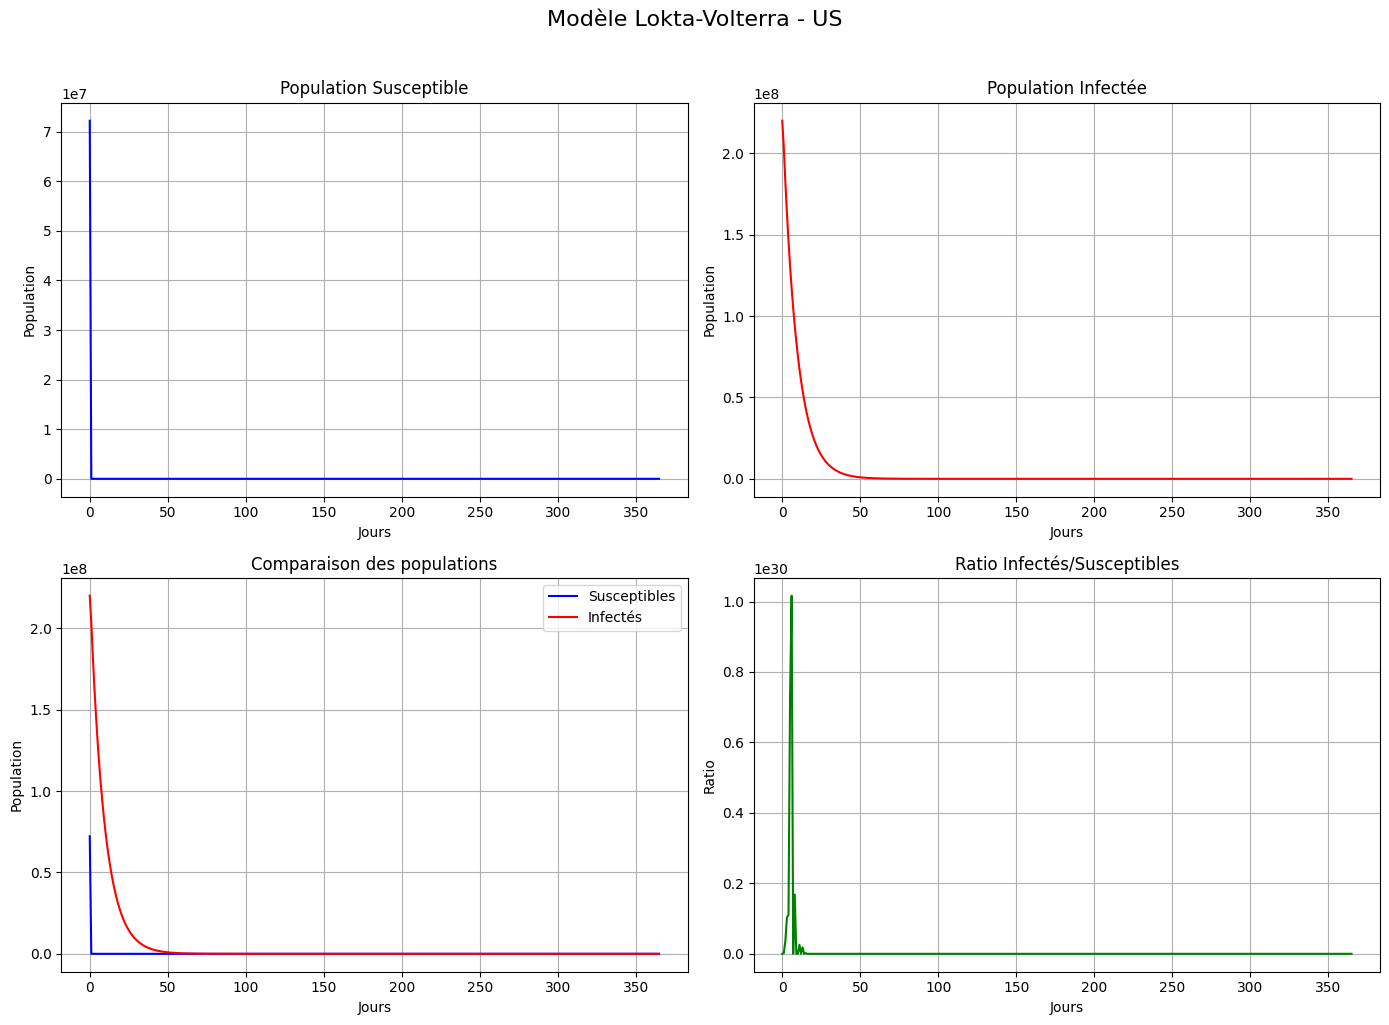

In [26]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def lokta_volterra(y, t, alpha, beta, delta, gamma, epsilon, phi):
    x, y = y
    dxdt = x * (alpha - beta * y) - epsilon * x
    dydt = y * (delta * x - gamma) - phi * y
    return [dxdt, dydt]

# Paramètres initiaux
alpha = 0.1
beta = 0.01
delta = 0.001
gamma = 0.1
epsilon = 0.01
phi = 0.01

# Simulation sur 1 an
t_span = np.linspace(0, 365, 365)

# Pour chaque pays
for country in pays:
    # Récupération des conditions initiales
    country_data = df_lv[df_lv['country'] == country].iloc[-1]
    x0 = country_data['x(t)']
    y0 = country_data['y(t)']

    # Simulation
    solution = odeint(lokta_volterra, [x0, y0], t_span,
                     args=(alpha, beta, delta, gamma, epsilon, phi))

    # Création de la figure avec 4 subplots
    plt.figure(figsize=(14, 10))
    plt.suptitle(f'Modèle Lokta-Volterra - {country}', fontsize=16, y=1.02)

    # Subplot 1: Population Susceptible
    plt.subplot(2, 2, 1)
    plt.plot(t_span, solution[:, 0], 'b-')
    plt.title('Population Susceptible')
    plt.xlabel('Jours')
    plt.ylabel('Population')
    plt.grid()

    # Subplot 2: Population Infectée
    plt.subplot(2, 2, 2)
    plt.plot(t_span, solution[:, 1], 'r-')
    plt.title('Population Infectée')
    plt.xlabel('Jours')
    plt.ylabel('Population')
    plt.grid()

    # Subplot 3: Comparaison des deux populations
    plt.subplot(2, 2, 3)
    plt.plot(t_span, solution[:, 0], 'b-', label='Susceptibles')
    plt.plot(t_span, solution[:, 1], 'r-', label='Infectés')
    plt.title('Comparaison des populations')
    plt.xlabel('Jours')
    plt.ylabel('Population')
    plt.legend()
    plt.grid()

    # Subplot 4: Ratio Infectés/Susceptibles
    plt.subplot(2, 2, 4)
    ratio = np.where(solution[:, 0] > 0, solution[:, 1]/solution[:, 0], 0)  # Évite division par zéro
    plt.plot(t_span, ratio, 'g-')
    plt.title('Ratio Infectés/Susceptibles')
    plt.xlabel('Jours')
    plt.ylabel('Ratio')
    plt.grid()

    plt.tight_layout()
    plt.show()

In [28]:
# prompt: install tabulate

!pip install tabulate

In [30]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 4.2 MB/s eta 0:00:00


In [33]:
# PROJET BASE MACHINE LEARNING - KHADIM DIOPO
import pandas as pd
from tabulate import tabulate

# =========================================================================
# PROBLÈME 1 : Récapitulatif des performances polynomiales
# =========================================================================

def create_problem1_summary(all_results_confirmed, all_results_recovered):
    # Création des DataFrames pour les cas confirmés et guéris
    summary_dfs = []

    for target, all_results in [('Confirmés', all_results_confirmed),
                              ('Guéris', all_results_recovered)]:
        data = []

        for country in pays:
            for degree, metrics in all_results[country].items():
                data.append({
                    'Pays': country,
                    'Cible': target,
                    'Degré': degree,
                    'MSE Train': f"{metrics['mse_train']:.2e}",
                    'MSE Test': f"{metrics['mse_test']:.2e}",
                    'R² Train': f"{metrics['r2_train']:.4f}",
                    'R² Test': f"{metrics['r2_test']:.4f}"
                })

        df = pd.DataFrame(data)
        summary_dfs.append(df)

    # Fusionner les deux tableaux
    full_summary_pb1 = pd.concat(summary_dfs)

    # Trier par pays et degré
    full_summary_pb1 = full_summary_pb1.sort_values(['Pays', 'Cible', 'Degré'])

    return full_summary_pb1

# Génération du tableau
summary_pb1 = create_problem1_summary(all_results_confirmed, all_results_recovered)

# Affichage markdown (pour Colab/Jupyter)
print("="*80)
print("PROBLÈME 1 : RÉCAPITULATIF DES PERFORMANCES POLYNOMIALES")
print("="*80)
print(tabulate(summary_pb1, headers='keys', tablefmt='grid', showindex=False))

# =========================================================================
# PROBLÈME 2 : Récapitulatif des paramètres de Lokta-Volterra
# =========================================================================

def create_problem2_summary(params_eq1, params_eq2):
    data = []

    for country in pays:
        # Paramètres de la première équation
        eq1 = params_eq1[country]
        # Paramètres de la seconde équation
        eq2 = params_eq2[country]

        data.append({
            'Pays': country,
            'α - ε': f"{eq1['α - ε']:.6f}",
            'β': f"{eq1['β']:.6f}",
            'δ': f"{eq2['δ']:.6f}",
            'γ + φ': f"{eq2['γ + φ']:.6f}",
            'R² (Éq1)': f"{eq1['r2_score']:.4f}",
            'R² (Éq2)': f"{eq2['r2_score']:.4f}"
        })

    return pd.DataFrame(data)

# Génération du tableau
summary_pb2 = create_problem2_summary(params_eq1, params_eq2)

# Affichage markdown
print("\n" + "="*80)
print("PROBLÈME 2 : PARAMÈTRES DE LOKTA-VOLTERRA")
print("="*80)
print(tabulate(summary_pb2, headers='keys', tablefmt='grid', showindex=False))


PROBLÈME 1 : RÉCAPITULATIF DES PERFORMANCES POLYNOMIALES
+---------------+-----------+---------+---------------+---------------+------------+-----------+
| Pays          | Cible     |   Degré |     MSE Train |      MSE Test |   R² Train |   R² Test |
+===============+===========+=========+===============+===============+============+===========+
| Burkina Faso  | Confirmés |       3 |      1.26e+06 |      1.2e+08  |     0.9961 |    0.018  |
+---------------+-----------+---------+---------------+---------------+------------+-----------+
| Burkina Faso  | Confirmés |       4 | 138000        |      1.45e+08 |     0.9996 |   -0.1887 |
+---------------+-----------+---------+---------------+---------------+------------+-----------+
| Burkina Faso  | Confirmés |       5 | 138000        |      1.27e+08 |     0.9996 |   -0.0371 |
+---------------+-----------+---------+---------------+---------------+------------+-----------+
| Burkina Faso  | Confirmés |       6 |  36800        |      7.77e+08 

Exam - BML - Khadim DIOP